In [1]:
#Import libraries and specify paths

import pandas as pd
import numpy  as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
import shap

import time
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.metrics import confusion_matrix


#import pytorch since tensorflow is not supporting in python 3.14
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

torch.manual_seed(42)

print("Librarties imported")

train_csv=r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_train.csv"
test_csv=r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_test.csv"

print("Paths are set")

Librarties imported
Paths are set


In [2]:
#load train and test data

train_df=pd.read_csv(train_csv)
test_df=pd.read_csv(test_csv)

print(f"Train CSV: {train_df.shape}")
print(f"Test CSV: {test_df.shape}")

print(f"\nTrain label Distribution: {train_df['label'].value_counts().to_dict()}")
print(f"\nTest label Distribution: {test_df['label'].value_counts().to_dict()}")

Train CSV: (32000, 104)
Test CSV: (8000, 104)

Train label Distribution: {0: 16000, 1: 16000}

Test label Distribution: {1: 4000, 0: 4000}


In [3]:
#Separate features and label

feature_columns=[feature for feature in train_df.columns if feature!='label']

X_train=train_df[feature_columns]
y_train=train_df['label']

X_test=test_df[feature_columns]
y_test=test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

X_train shape: (32000, 103)
X_test shape: (8000, 103)
y_train distribution: {0: 16000, 1: 16000}
y_test distribution: {1: 4000, 0: 4000}


In [4]:
#DNN Architecture

class TorchDNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

class DNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42):
        self.epochs=epochs
        self.batch_size=batch_size
        self.lr=lr
        self.patience=patience
        self.random_state=random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)

        X=np.asarray(X, dtype=np.float32)
        y=np.asarray(y, dtype=np.float32).reshape(-1,1)

        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.1, random_state=self.random_state, stratify=y)

        self.model_= TorchDNN(X.shape[1])
        optimizer=torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        loss_function=nn.BCELoss()

        X_tr_t = torch.tensor(X_tr)
        y_tr_t = torch.tensor(y_tr)
        X_val_t = torch.tensor(X_val)
        y_val_t = torch.tensor(y_val)

        best_val_loss = float('inf')
        best_state=None
        epoch_no_improve=0
        n_samples=X_tr_t.shape[0]

        for epoch in range(self.epochs):
            self.model_.train()
            permutation=torch.randperm(n_samples)

            for i in range (0, n_samples, self.batch_size):
                idx=permutation[i : i + self.batch_size]
                batch_X, batch_y = X_tr_t[idx], y_tr_t[idx]

                optimizer.zero_grad()
                outputs=self.model_(batch_X)
                loss=loss_function(outputs, batch_y)
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss=loss_function(self.model_(X_val_t), y_val_t).item()

            if val_loss < best_val_loss:
                best_val_loss=val_loss
                best_state={k: v.clone() for k, v in self.model_.state_dict().items()}
                epoch_no_improve=0
            else:
                epoch_no_improve=epoch_no_improve+1
                if epoch_no_improve >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.classes_=np.array([0,1])
        return self

    def predict_proba(self,X):
        X=np.asarray(X, dtype=np.float32)
        self.model_.eval()
        with torch.no_grad():
            probs=self.model_(torch.tensor(X)).numpy().flatten()
        return np.column_stack([1-probs, probs])

    def predict(self,X):
        probs=self.predict_proba(X)[:,1]
        return (probs>=0.5).astype(int)

# Definition of all models

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'DNN': DNNClassifier(epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42)
}

print("Models Defined:")
for i in models:
    print(i)

Models Defined:
Decision Tree
Random Forest
KNN
SVM
Logistic Regression
XGBoost
DNN


In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cross_validation_results=[]

print("Running 5-fold Cross-validation on training set....")

for model_name, model in models.items():
    print(f"\nCross Validating {model_name}....")

    cross_validadtion_scores=cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")

    cross_validation_results.append({
        "Model": model_name,
        "CV Mean F1": round(cross_validadtion_scores.mean(),4),
        "CV Std F1": round(cross_validadtion_scores.std(),4),
        "CV Min F1": round(cross_validadtion_scores.min(),4),
        "CV Max F1": round(cross_validadtion_scores.max(),4)
    })

    print(f"Fold Scores: {[round(s,4) for s in cross_validadtion_scores]}")
    print(f"Mean F1: {cross_validadtion_scores.mean()}")
    print(f"Std F1: {cross_validadtion_scores.std()}")

cross_validation_results_df=pd.DataFrame(cross_validation_results)
cross_validation_results_df=cross_validation_results_df.sort_values('CV Mean F1', ascending =False).reset_index(drop=True)
print("Cross Validation Results:\n")
print(cross_validation_results_df.to_string(index=False))

Running 5-fold Cross-validation on training set....

Cross Validating Decision Tree....
Fold Scores: [np.float64(0.9825), np.float64(0.9848), np.float64(0.9851), np.float64(0.9834), np.float64(0.9829)]
Mean F1: 0.9837531154366467
Std F1: 0.001047233282588266

Cross Validating Random Forest....
Fold Scores: [np.float64(0.9852), np.float64(0.9869), np.float64(0.9874), np.float64(0.9855), np.float64(0.9863)]
Mean F1: 0.9862749235729262
Std F1: 0.0008379174399847061

Cross Validating KNN....
Fold Scores: [np.float64(0.978), np.float64(0.9824), np.float64(0.9819), np.float64(0.9791), np.float64(0.978)]
Mean F1: 0.9798710972383757
Std F1: 0.0019019772703113144

Cross Validating SVM....
Fold Scores: [np.float64(0.9674), np.float64(0.9702), np.float64(0.9731), np.float64(0.9691), np.float64(0.9671)]
Mean F1: 0.9693822359058641
Std F1: 0.002163193785240415

Cross Validating Logistic Regression....
Fold Scores: [np.float64(0.9672), np.float64(0.9703), np.float64(0.9724), np.float64(0.9693), np.f

Training Decision Tree....
Model Name: Decision Tree
Accuracy 0.98325
Precision: 0.9854344550477148
Recall: 0.981
F1-Score: 0.9832122275119017
Training Time: 3.0930795669555664 seconds
Testing Time: 0.009698867797851562 seconds


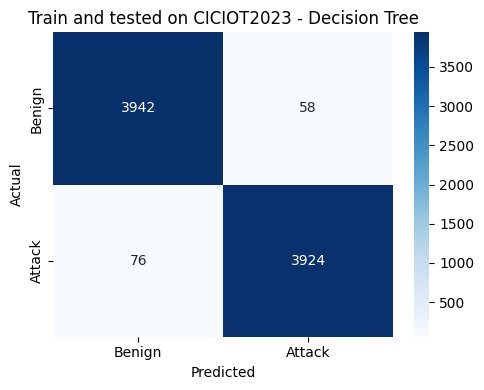

Training Random Forest....
Model Name: Random Forest
Accuracy 0.98675
Precision: 0.9919151086407276
Recall: 0.9815
F1-Score: 0.9866800703694396
Training Time: 20.025360584259033 seconds
Testing Time: 0.10122513771057129 seconds


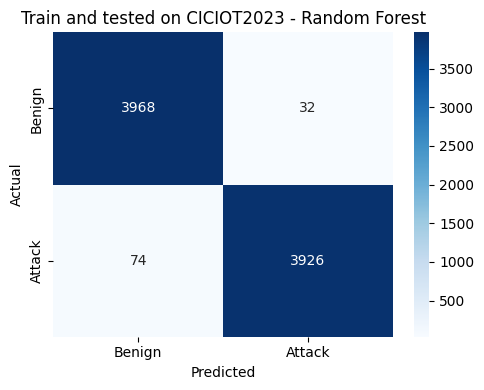

Training KNN....
Model Name: KNN
Accuracy 0.980375
Precision: 0.9843710612553567
Recall: 0.97625
F1-Score: 0.9802937115601857
Training Time: 0.04058957099914551 seconds
Testing Time: 1.884364128112793 seconds


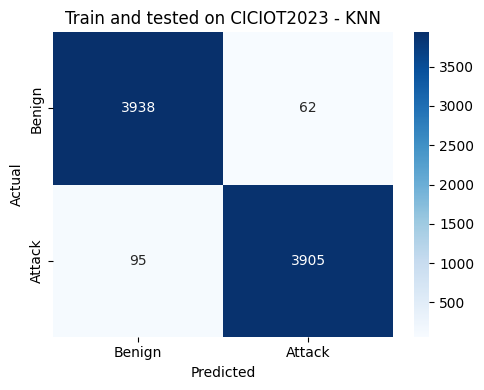

Training SVM....
Model Name: SVM
Accuracy 0.974875
Precision: 0.9984256100760955
Recall: 0.95125
F1-Score: 0.9742670592753808
Training Time: 143.11565256118774 seconds
Testing Time: 4.153303146362305 seconds


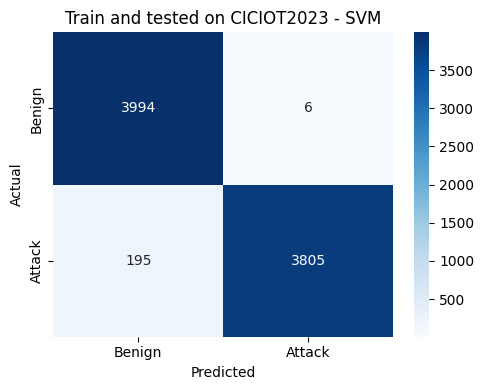

Training Logistic Regression....
Model Name: Logistic Regression
Accuracy 0.97525
Precision: 0.9976439790575916
Recall: 0.95275
F1-Score: 0.9746803069053709
Training Time: 2.3257081508636475 seconds
Testing Time: 0.011350631713867188 seconds


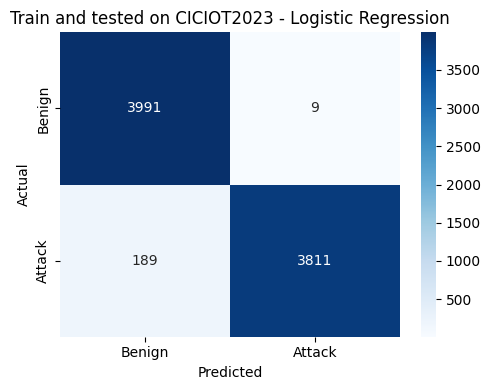

Training XGBoost....
Model Name: XGBoost
Accuracy 0.988625
Precision: 0.9902182091798345
Recall: 0.987
F1-Score: 0.9886064855390009
Training Time: 3.5864200592041016 seconds
Testing Time: 0.023508787155151367 seconds


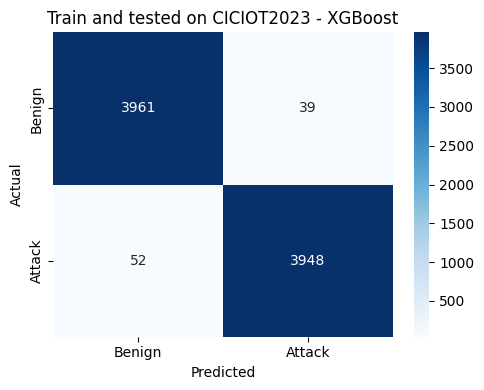

Training DNN....
Model Name: DNN
Accuracy 0.977375
Precision: 0.9989547948784949
Recall: 0.95575
F1-Score: 0.976874920148205
Training Time: 24.42324995994568 seconds
Testing Time: 0.013701438903808594 seconds


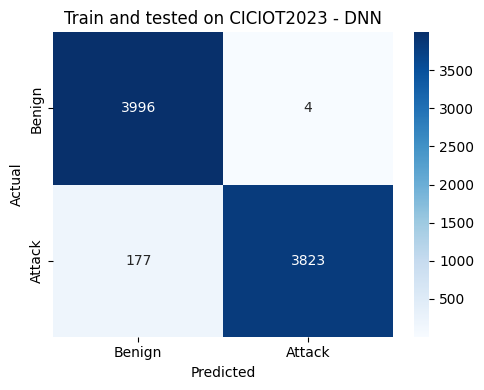


 All models are trained and evaluated


In [6]:
#Train and evaluate all models

results=[]

for model_name, model in models.items():
    print(f"Training {model_name}....")

    #train the model on train data
    start_time=time.time()
    model.fit(X_train, y_train)
    end_time=time.time()
    training_time=end_time-start_time

    #predict on test data
    start_time=time.time()
    y_pred=model.predict(X_test)
    end_time=time.time()
    testing_time=end_time-start_time
    
    #metrics calculation
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)

    #Storing results
    results.append({
         'Model': model_name,
         'Accuracy': round(accuracy,4),
         'Precision': round(precision,4),
         'Recall': round(recall,4),
         'F1-Score': round(f1,4),
         'Training Time (S)': training_time,
         'Testing Time (S)': testing_time
     })
    print(f"Model Name: {model_name}")
    print(f"Accuracy {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"Training Time: {training_time} seconds")
    print(f"Testing Time: {testing_time} seconds")

    #plot confusion matrix,
    cm=confusion_matrix(y_test, y_pred)
    fig,ax=plt.subplots(figsize=(5,4))
    sbn.heatmap(
    cm, annot=True, fmt='d',cmap='Blues',
    xticklabels=['Benign', 'Attack'],
    yticklabels=['Benign', 'Attack'],
    ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"Train and tested on CICIOT2023 - {model_name}")
    plt.tight_layout()
    plt.show()
    plt.close()
     

print("\n All models are trained and evaluated")       
    

In [7]:
results_df=pd.DataFrame(results)

results_df=results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("CICIOT2023 Model Comparision:")
print(results_df.to_string(index=False))

CICIOT2023 Model Comparision:
              Model  Accuracy  Precision  Recall  F1-Score  Training Time (S)  Testing Time (S)
            XGBoost    0.9886     0.9902  0.9870    0.9886           3.586420          0.023509
      Random Forest    0.9868     0.9919  0.9815    0.9867          20.025361          0.101225
      Decision Tree    0.9832     0.9854  0.9810    0.9832           3.093080          0.009699
                KNN    0.9804     0.9844  0.9762    0.9803           0.040590          1.884364
                DNN    0.9774     0.9990  0.9557    0.9769          24.423250          0.013701
Logistic Regression    0.9752     0.9976  0.9527    0.9747           2.325708          0.011351
                SVM    0.9749     0.9984  0.9513    0.9743         143.115653          4.153303


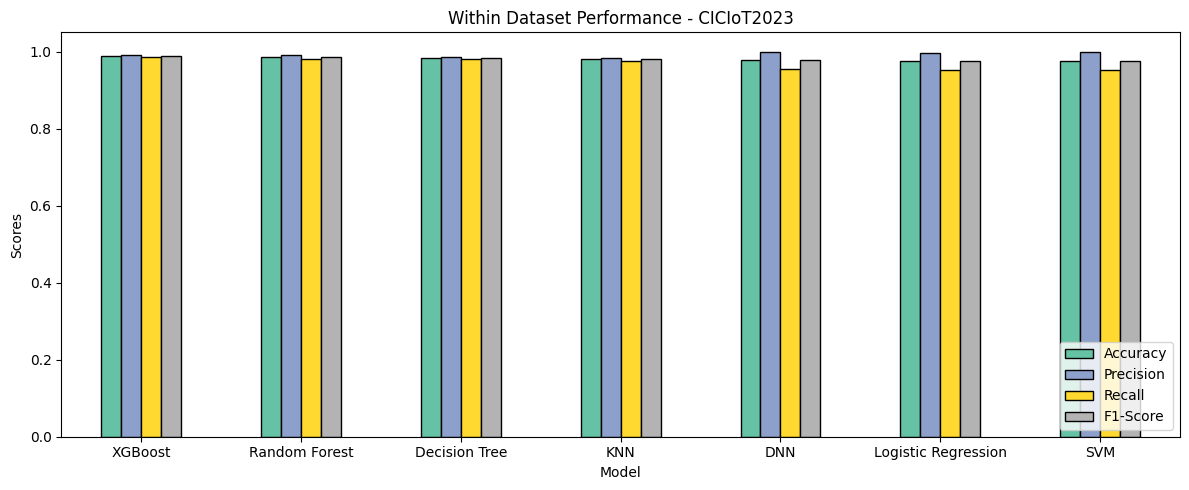

In [8]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].copy()
plot_df = plot_df.apply(pd.to_numeric, errors="coerce")

plot_df.plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Within Dataset Performance - CICIoT2023")
plt.xlabel("Model")
plt.ylabel("Scores")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
#SHAP Feature Importance

#as SHAP is very slow on large datasets. A subsample of both train and test set will be taken

train_sample=shap.sample(X_train, 100, random_state=42)

test_sample=X_test.sample(200, random_state=42)

print(f"Train sample shape: {train_sample.shape}")
print(f"Test sample shape: {test_sample.shape}")


Train sample shape: (100, 103)
Test sample shape: (200, 103)


Computing SHAP values for Decision Tree...


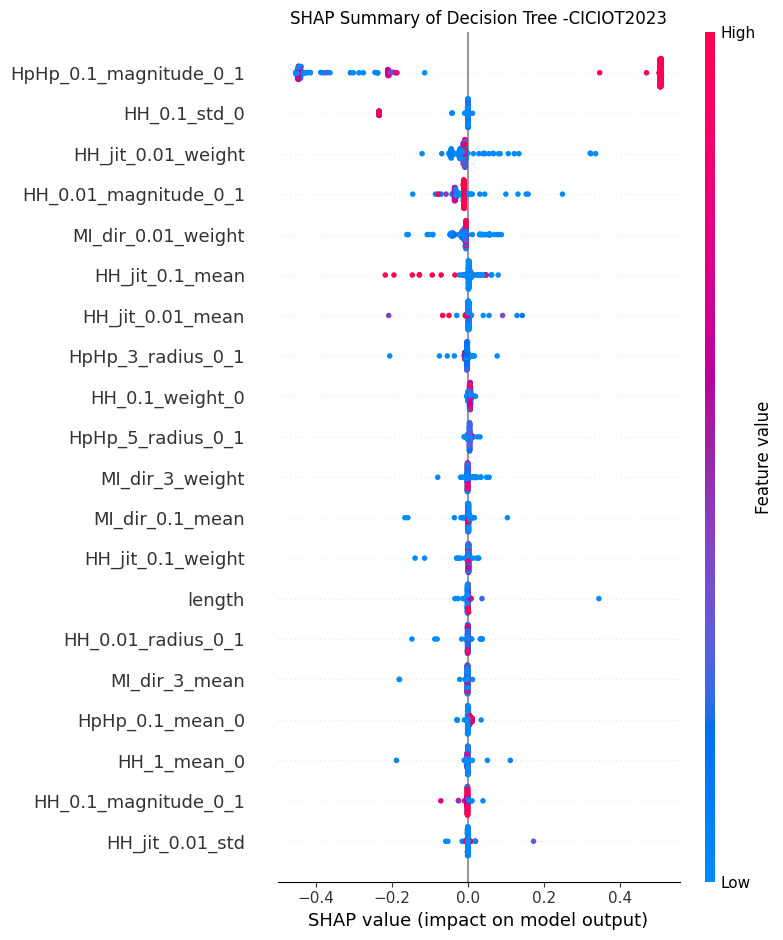

Computing SHAP values for Random Forest...


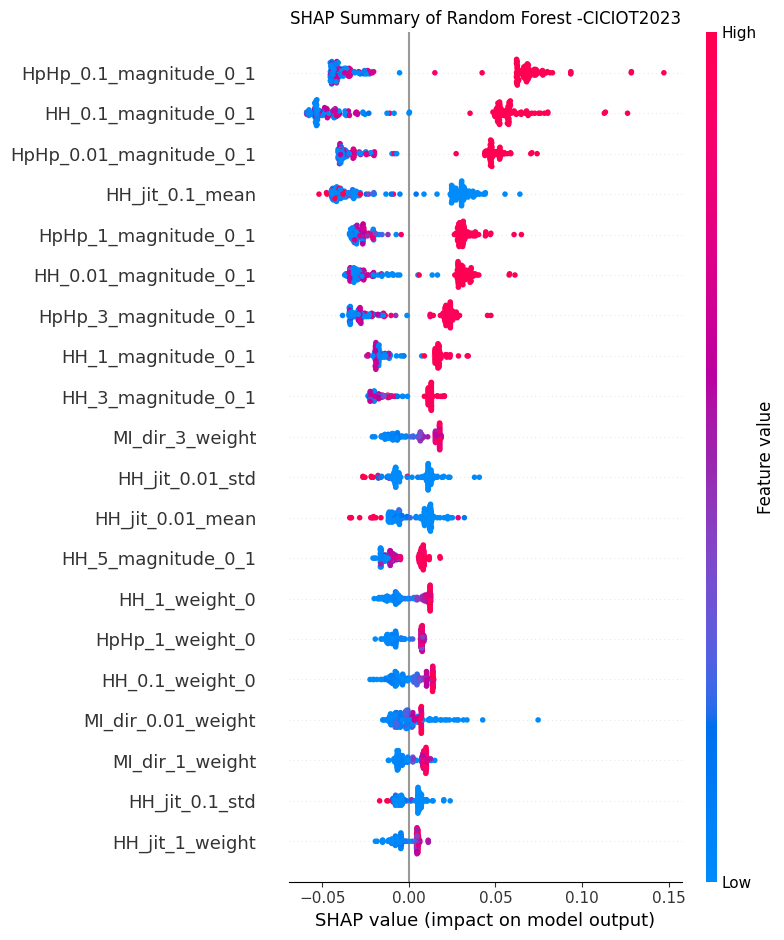

Computing SHAP values for XGBoost...


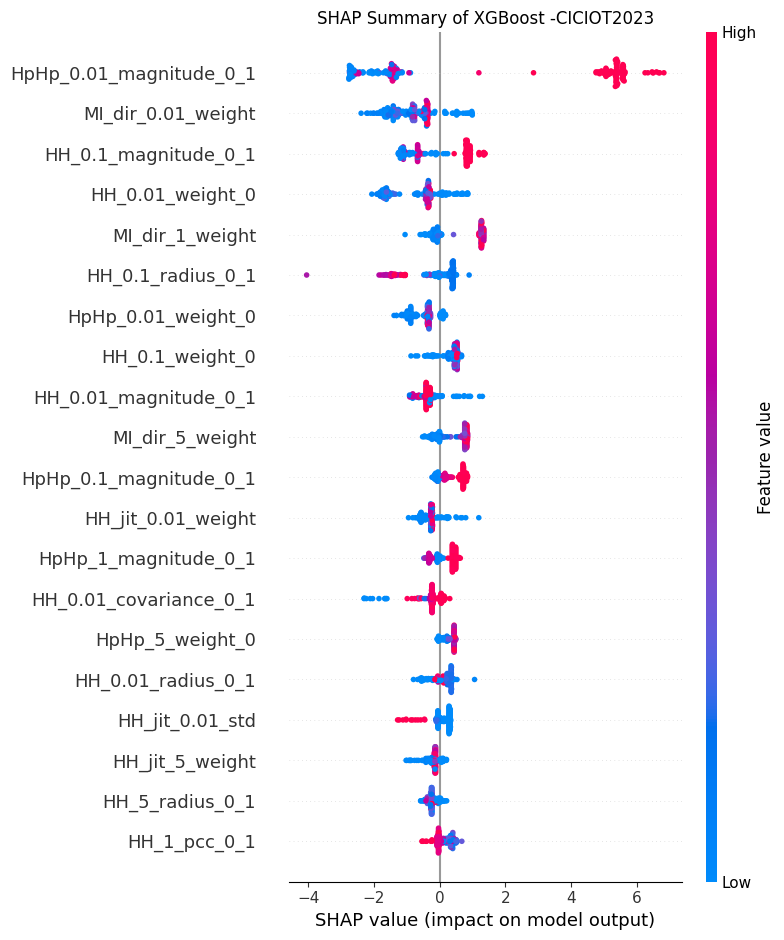

Tree-based SHAP values are calculated


In [10]:
#SHAP for tree-based models (Decision Tree, Random Forest and XGBoost)

tree_based_models = ["Decision Tree", "Random Forest", "XGBoost"]
tree_shap_values={}

for model_name in tree_based_models:
    print(f"Computing SHAP values for {model_name}...")
    explainer=shap.TreeExplainer(models[model_name])
    shap_values=explainer.shap_values(test_sample)

    shap_values=np.array(shap_values)
    if shap_values.ndim==3:
        shap_values=shap_values[:,:,1]

    tree_shap_values[model_name]=shap_values

    plt.figure()
    shap.summary_plot(shap_values, test_sample, show=False)
    plt.title(f"SHAP Summary of {model_name} -CICIOT2023")
    plt.tight_layout()
    plt.show()

print("Tree-based SHAP values are calculated")

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.


Computing SHAP values for Logistic Regression...


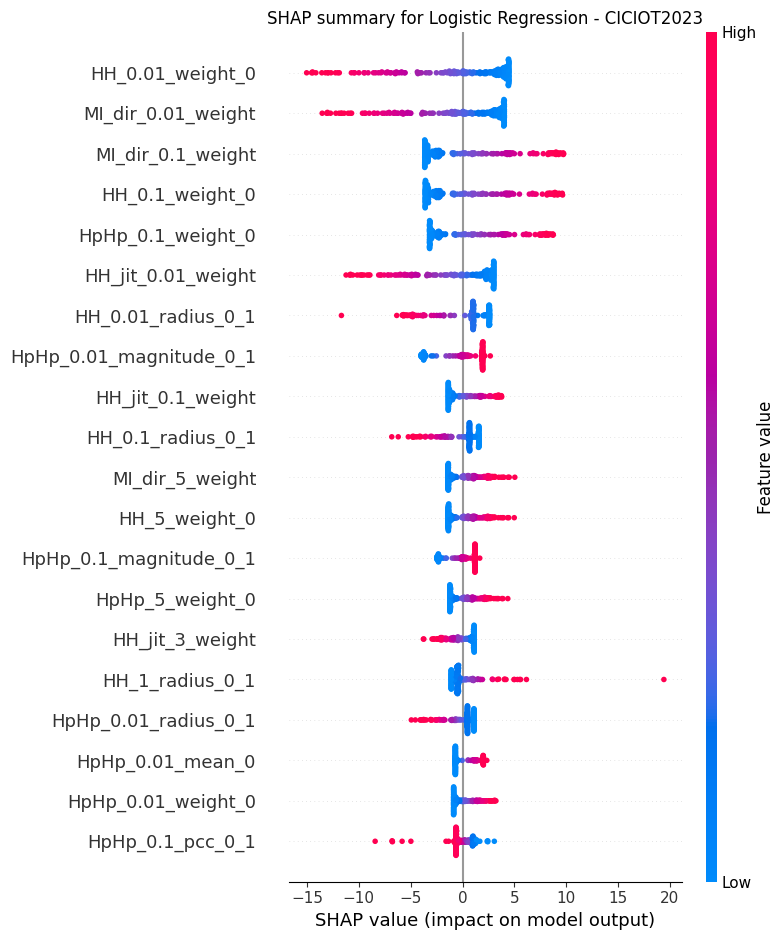

In [11]:
#SHAP for Logistic Regression

print("Computing SHAP values for Logistic Regression...")
lr_explainer=shap.LinearExplainer(models['Logistic Regression'], X_train, max_samples=32000)
lr_shap_values=lr_explainer.shap_values(test_sample)

plt.figure()
shap.summary_plot(lr_shap_values, test_sample, show=False)
plt.title("SHAP summary for Logistic Regression - CICIOT2023")
plt.tight_layout()
plt.show()

Computing SHAP values for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [48:37<00:00, 58.34s/it]


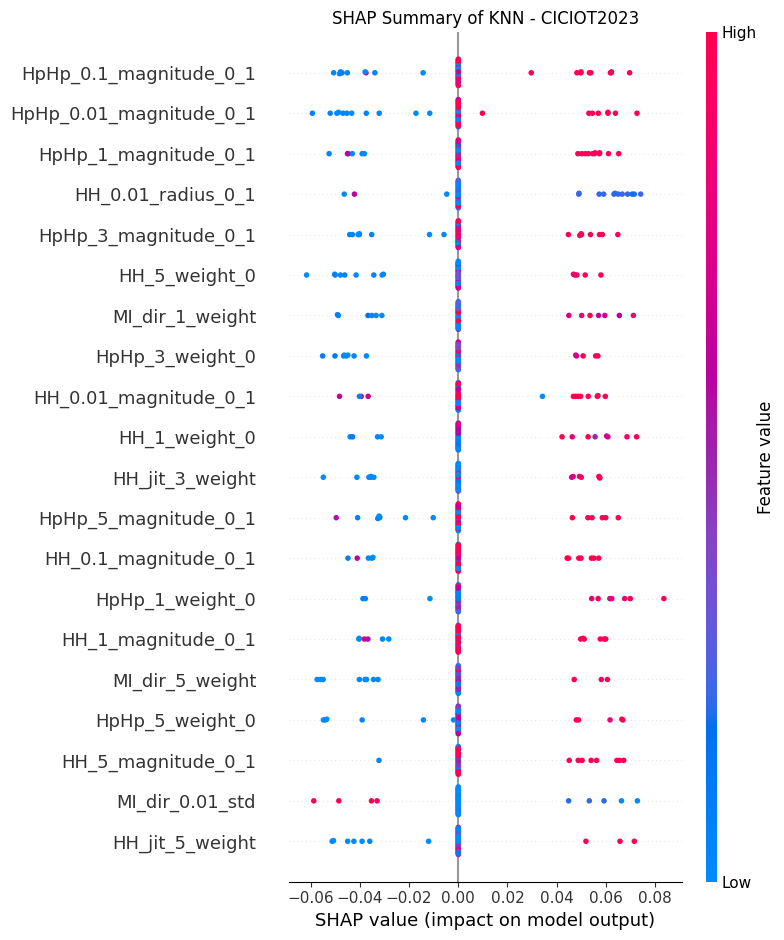

Computing SHAP values for SVM...


100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [3:00:43<00:00, 216.88s/it]


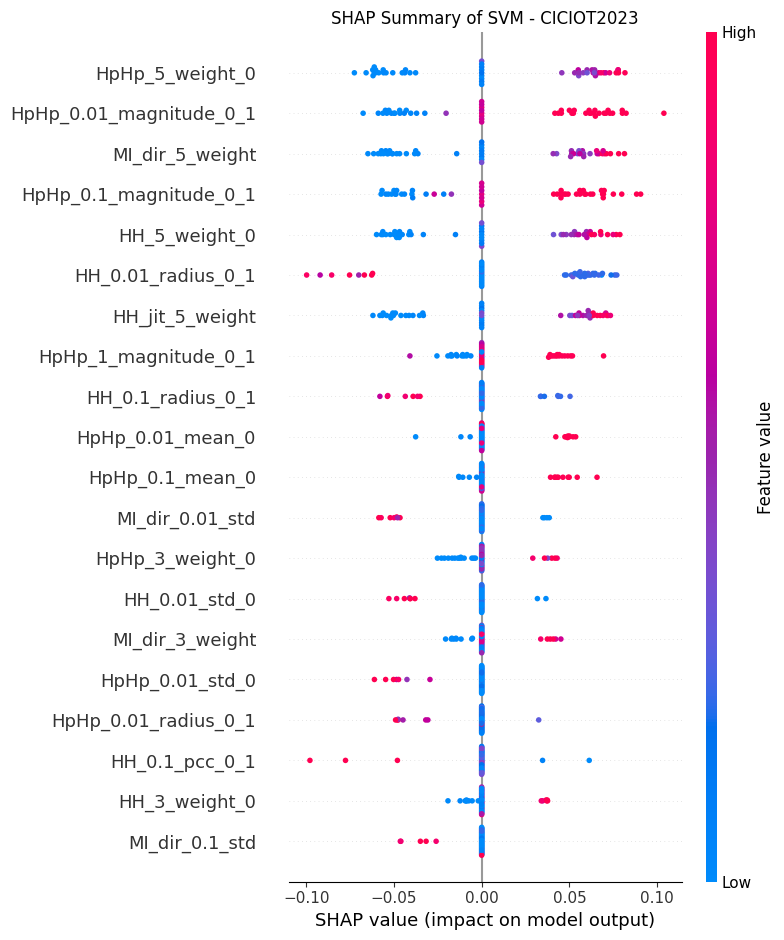

KN Nand SVM SHAP values are calculated


In [12]:
#SHAP for KNN and SVM

kernel_models = ["KNN", "SVM"]
kernel_sample=test_sample.sample(50, random_state=42)
kernel_shap_values = {}

for model_name in kernel_models:
    print(f"Computing SHAP values for {model_name}...")
    model=models[model_name]

    k_explainer=shap.KernelExplainer(model.predict_proba, train_sample)
    shap_values=k_explainer.shap_values(kernel_sample, nsample=100)

    shap_values=np.array(shap_values)
    if shap_values.ndim==3:
        shap_values=shap_values[:,:,1]

    kernel_shap_values[model_name]=shap_values

    plt.figure()
    shap.summary_plot(shap_values, kernel_sample, show=False)
    plt.title(f"SHAP Summary of {model_name} - CICIOT2023")
    plt.tight_layout()
    plt.show()

print("KN Nand SVM SHAP values are calculated")

Computing SHAP values for DNN...


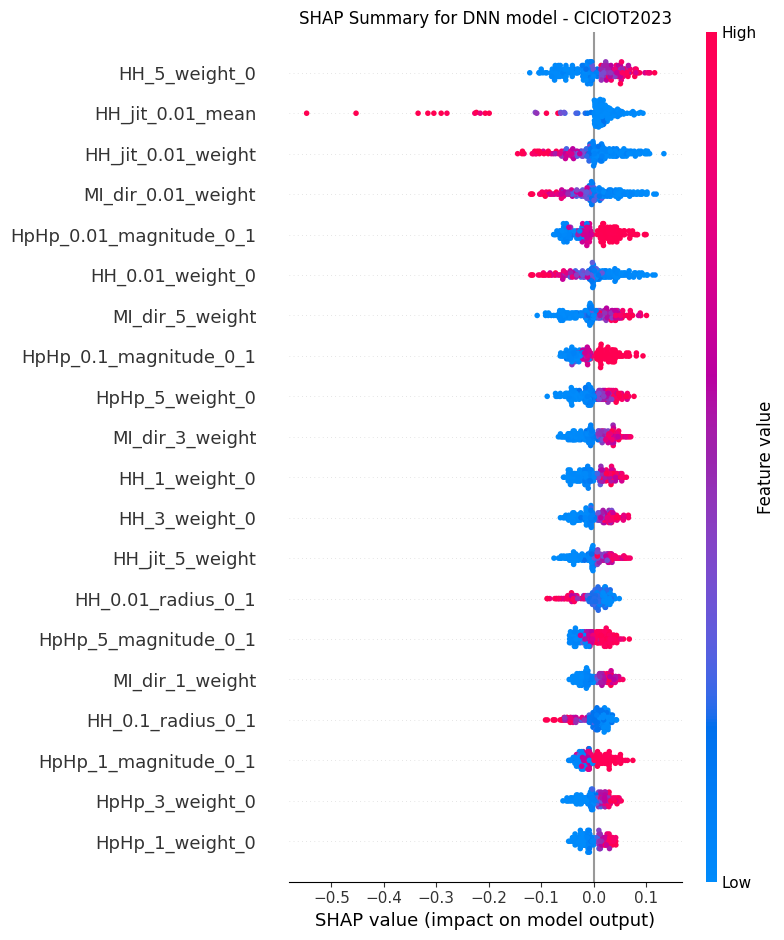

DNN SHAP values are calculated.


In [14]:
#SHAP for DNN model

print("Computing SHAP values for DNN...")

dnn_model=models["DNN"].model_
dnn_model.eval()

train_sample_t=torch.tensor(train_sample.values.astype('float32'))
test_sample_t=torch.tensor(test_sample.values.astype('float32'))

dnn_explainer=shap.GradientExplainer(dnn_model, test_sample_t)
dnn_shap_values=dnn_explainer.shap_values(test_sample_t)

if isinstance(dnn_shap_values, list):
    dnn_shap_values=dnn_shap_values[0]

dnn_shap_values=np.squeeze(dnn_shap_values)

plt.figure()
shap.summary_plot(dnn_shap_values, test_sample, show=False)
plt.title("SHAP Summary for DNN model - CICIOT2023")
plt.tight_layout()
plt.show()

print("DNN SHAP values are calculated.")